In [6]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000115 (2).png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000115 (5).png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000112.png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000118 (5).png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (4).png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000114 (6).png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (6).png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000114 (4).png
/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000118 (4).png
/kaggle/input/chest-cts

In [7]:
import shutil  # Import the shutil module for file operations
import os  # Import the os module for path operations

input_path = "/kaggle/input/chest-ctscan-images/Data"  # Source path of dataset
dataset_path = "/kaggle/working/Data"  # Destination path for copied dataset

# Copy dataset if it doesn't already exist
if not os.path.exists(dataset_path):
    shutil.copytree(input_path, dataset_path)  # Copy the directory tree
    print(f"Dataset telah disalin ke {dataset_path}")  # Print confirmation message

# Mapping of old folder names to new folder names
rename_mapping = {
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib": "adenocarcinoma",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa": "large.cell.carcinoma",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa": "squamous.cell.carcinoma"
}  

# Function to rename folders based on the mapping
def rename_folders(base_path, mapping):
    for old_name, new_name in mapping.items():
        old_path = os.path.join(base_path, old_name)  # Full path of old folder
        new_path = os.path.join(base_path, new_name)  # Full path of new folder

        if os.path.exists(old_path):  # Check if old folder exists
            if os.path.exists(new_path):  # Check if new folder already exists
                # Move contents from old folder to new folder
                for filename in os.listdir(old_path):
                    shutil.move(os.path.join(old_path, filename), os.path.join(new_path, filename))
                os.rmdir(old_path)  # Remove the old folder after moving contents
            else:
                os.rename(old_path, new_path)  # Rename old folder to new folder
            print(f"Folder '{old_name}' change to '{new_name}'.")  # Print rename confirmation

# Loop through each subset to rename folders
for subset in ["train", "valid", "test"]:
    subset_path = os.path.join(dataset_path, subset)  # Path to the subset
    rename_folders(subset_path, rename_mapping)  # Call the rename function

Dataset telah disalin ke /kaggle/working/Data
Folder 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib' change to 'adenocarcinoma'.
Folder 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa' change to 'large.cell.carcinoma'.
Folder 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa' change to 'squamous.cell.carcinoma'.
Folder 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib' change to 'adenocarcinoma'.
Folder 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa' change to 'large.cell.carcinoma'.
Folder 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa' change to 'squamous.cell.carcinoma'.


In [8]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

# Transformations for the training dataset (including augmentation)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomRotation(20),  # Rotate images up to 20 degrees
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Randomly crop to 224x224
    transforms.RandomAffine(degrees=10, shear=5),  # Apply random affine transformations
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize images
])

# Transformations for the validation dataset (no augmentation)
valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize images
])

# Load the ImageFolder dataset with the specified transformations
train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train", transform=train_transforms)
valid_dataset = datasets.ImageFolder(root=f"{dataset_path}/valid", transform=valid_transforms)
test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test", transform=valid_transforms)  # Use validation transforms for test data

# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Shuffle training data
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)  # Do not shuffle validation data
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # Do not shuffle test data

# Print the mapping of class names to indices
print(train_dataset.class_to_idx)

{'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}


In [9]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights

# Custom neural network class based on ResNet-18
class CustomResNet18(nn.Module):
    def __init__(self, num_classes):
        super(CustomResNet18, self).__init__()
        
        # Load pre-trained ResNet18 model
        self.resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # Remove the original fully connected (FC) layer
        in_features = self.resnet.fc.in_features  # Get the number of input features for the original FC layer
        self.resnet.fc = nn.Identity()  # Replace the original FC layer with an identity layer to effectively remove it

        # Define a new custom fully connected layer
        self.fc = nn.Sequential(
            nn.Dropout(0.7),                 # Dropout layer to mitigate overfitting before the first FC layer
            nn.Linear(in_features, 256),     # Fully connected layer with input size from ResNet and output size of 256
            nn.ReLU(),                       # ReLU activation function
            nn.Flatten(),                    # Flatten the output from the previous layer
            nn.Dropout(0.7),                 # Another dropout layer after the activation
            nn.Linear(256, num_classes)      # Output layer that maps to the specified number of classes
        )

    def forward(self, x):
        x = self.resnet(x)  # Pass input through the ResNet backbone
        x = self.fc(x)      # Pass through the custom fully connected layers
        return x

# Example usage of the CustomResNet18 model
num_classes = 10  # Adjust based on the number of classes in your dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check if GPU is available

# Instantiate the model and move it to the appropriate device
model = CustomResNet18(num_classes).to(device)

# Print model summary to inspect the architecture
from torchsummary import summary
summary(model, (3, 224, 224))  # Summary of the model for input images of size 224x224 with 3 color channels

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s] 


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

Evaluation: Accuracy=40.28%, Precision=0.6460, Recall=0.4793, F1-score=0.4096
Model saved! Train Loss: 2.1085, Train Acc: 25.45%, Valid Loss: 1.6067, Valid Acc: 40.28%
Epoch 1: Train Loss=2.1085, Train Acc=25.45%, Valid Loss=1.6067, Valid Acc=40.28%
Evaluation: Accuracy=45.83%, Precision=0.7015, Recall=0.5543, F1-score=0.4429
Model saved! Train Loss: 1.4953, Train Acc: 44.37%, Valid Loss: 1.2426, Valid Acc: 45.83%
Epoch 2: Train Loss=1.4953, Train Acc=44.37%, Valid Loss=1.2426, Valid Acc=45.83%
Evaluation: Accuracy=41.67%, Precision=0.6435, Recall=0.5217, F1-score=0.3953
Model saved! Train Loss: 1.2181, Train Acc: 52.04%, Valid Loss: 1.0150, Valid Acc: 41.67%
Epoch 3: Train Loss=1.2181, Train Acc=52.04%, Valid Loss=1.0150, Valid Acc=41.67%
Evaluation: Accuracy=45.83%, Precision=0.6905, Recall=0.5428, F1-score=0.4523
Model saved! Train Loss: 1.1003, Train Acc: 58.40%, Valid Loss: 0.9181, Valid Acc: 45.83%
Epoch 4: Train Loss=1.1003, Train Acc=58.40%, Valid Loss=0.9181, Valid Acc=45.83%


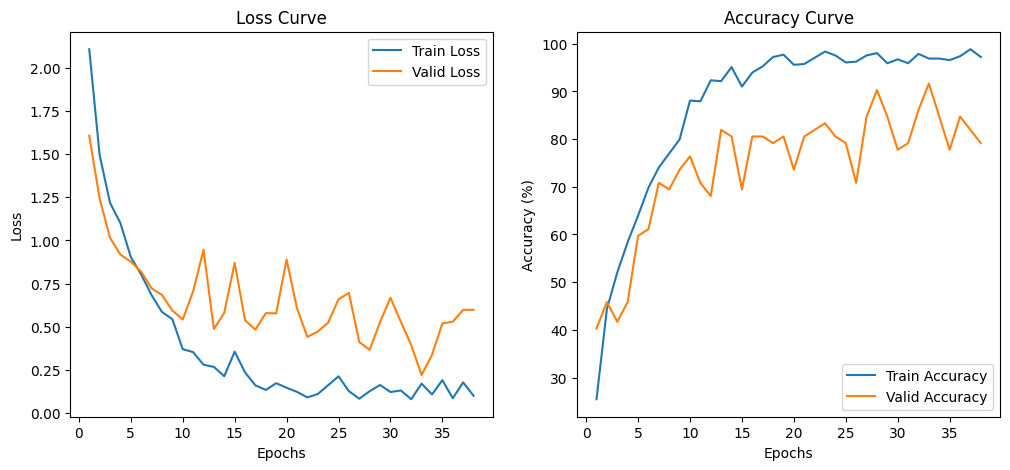

/tmp/ipykernel_31/3172918828.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Evaluation: Accuracy=90.79%, Precision=0.9005, Recall=0.9200, F1-score=0.9086
Best Test Accuracy: 90.79%


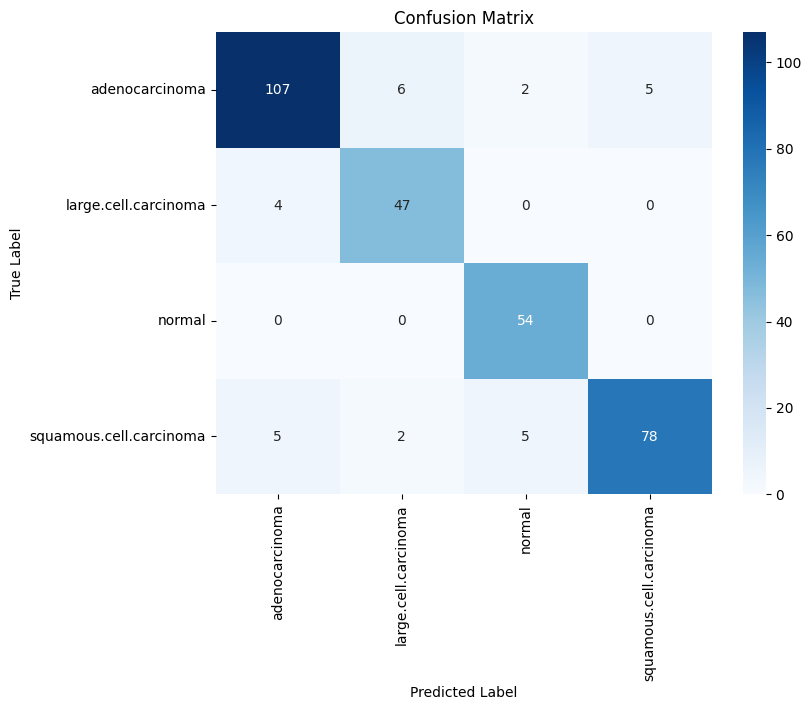

In [10]:
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from torch.optim.lr_scheduler import StepLR

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=15, gamma=0.5)  # Reduce learning rate every 15 epochs

def train_model(model, train_loader, valid_loader, epochs=30, save_path="best_model.pth", early_stopping_patience=5):
    best_valid_loss = float('inf')
    patience_counter = 0  # For early stopping
    
    train_losses, valid_losses, train_accs, valid_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total
        valid_acc, valid_loss = evaluate(model, valid_loader)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        # Save model if validation loss improves
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), save_path)
            print(f"Model saved! Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.2f}%")
            patience_counter = 0  # Reset if there is an improvement
        else:
            patience_counter += 1  # Increment counter if no improvement

        # Optional: Uncomment to use learning rate scheduler
        # scheduler.step(valid_loss)
        
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, Valid Loss={valid_loss:.4f}, Valid Acc={valid_acc:.2f}%")

        # Early Stopping
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at Epoch {epoch+1} due to no improvement for {early_stopping_patience} epochs.")
            break

    plot_training(train_losses, valid_losses, train_accs, valid_accs)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = 100 * correct / total
    avg_loss = total_loss / len(loader)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=1)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=1)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=1)
    
    print(f"Evaluation: Accuracy={acc:.2f}%, Precision={precision:.4f}, Recall={recall:.4f}, F1-score={f1:.4f}")
    return acc, avg_loss

def plot_training(train_losses, valid_losses, train_accs, valid_accs):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, valid_losses, label='Valid Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label='Train Accuracy')
    plt.plot(epochs, valid_accs, label='Valid Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Curve')
    plt.legend()
    
    plt.show()

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Training with early stopping
train_model(model, train_loader, valid_loader, epochs=100, save_path="best_model.pth", early_stopping_patience=5)

# Load the best model
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)

# Evaluate on the test set
test_acc, _ = evaluate(model, test_loader)
print(f"Best Test Accuracy: {test_acc:.2f}%")

# Generate and plot the confusion matrix for the best model
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plot_confusion_matrix(cm, test_loader.dataset.classes)

Epoch [1/100], Train Loss: 1.6828, Train Acc: 0.4486, Valid Loss: 1.2433, Valid Acc: 0.4167
Epoch [2/100], Train Loss: 0.9899, Train Acc: 0.6264, Valid Loss: 0.9154, Valid Acc: 0.3889
Epoch [3/100], Train Loss: 0.7713, Train Acc: 0.6868, Valid Loss: 0.7967, Valid Acc: 0.5972
Epoch [4/100], Train Loss: 0.6222, Train Acc: 0.7863, Valid Loss: 0.7264, Valid Acc: 0.6667
Epoch [5/100], Train Loss: 0.4002, Train Acc: 0.8744, Valid Loss: 0.6741, Valid Acc: 0.7361
Epoch [6/100], Train Loss: 0.2794, Train Acc: 0.9250, Valid Loss: 0.5389, Valid Acc: 0.8194
Epoch [7/100], Train Loss: 0.1931, Train Acc: 0.9396, Valid Loss: 0.5389, Valid Acc: 0.8056
Epoch [8/100], Train Loss: 0.1458, Train Acc: 0.9674, Valid Loss: 0.4361, Valid Acc: 0.8194
Epoch [9/100], Train Loss: 0.1228, Train Acc: 0.9641, Valid Loss: 0.6025, Valid Acc: 0.7639
Epoch [10/100], Train Loss: 0.0888, Train Acc: 0.9821, Valid Loss: 0.6686, Valid Acc: 0.7917
Epoch [11/100], Train Loss: 0.0754, Train Acc: 0.9804, Valid Loss: 0.3108, Vali

/tmp/ipykernel_31/1666449446.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load("best_densenet_model.pth"))


Evaluation: Accuracy=89.84%, Precision=0.9097, Recall=0.8872, F1-score=0.8968
Best Test Accuracy for DenseNet: 89.84%


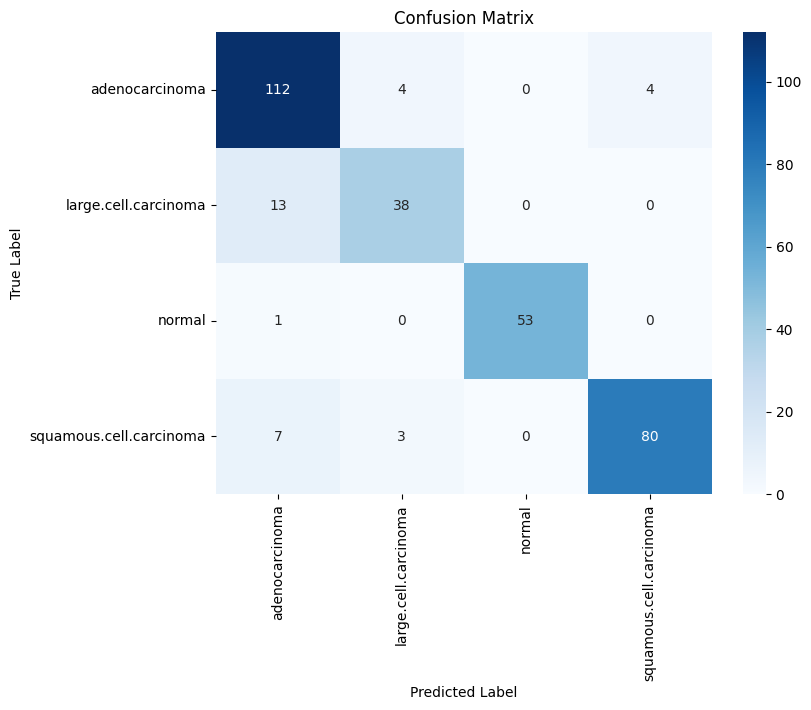

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import StepLR
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


class CustomDenseNet121(nn.Module):
    def __init__(self, num_classes):
        super(CustomDenseNet121, self).__init__()
        self.densenet = models.densenet121(weights='DEFAULT')  # Load pre-trained DenseNet-121
        in_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.densenet(x)


def train_model(model, train_loader, valid_loader, epochs, save_path, early_stopping_patience):
    best_valid_loss = float('inf')
    patience_counter = 0
    train_losses, valid_losses, train_accs, valid_accs = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        total_loss, total_correct, total_samples = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Backward pass
            loss.backward()
            optimizer.step()

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        # Calculate average loss and accuracy for the epoch
        train_loss = total_loss / len(train_loader)
        train_accuracy = total_correct / total_samples
        train_losses.append(train_loss)
        train_accs.append(train_accuracy)

        # Validation phase
        model.eval()
        valid_loss, valid_correct, valid_samples = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                valid_correct += (predicted == labels).sum().item()
                valid_samples += labels.size(0)

        valid_loss /= len(valid_loader)
        valid_accuracy = valid_correct / valid_samples
        valid_losses.append(valid_loss)
        valid_accs.append(valid_accuracy)

        # Print epoch results
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, '
              f'Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_accuracy:.4f}')

        # Check if we need to save the model
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            patience_counter = 0  # Reset patience
            torch.save(model.state_dict(), save_path)  # Save the best model
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    return train_losses, valid_losses, train_accs, valid_accs


# Instantiate and train your model
num_classes = 10  # Adjust this based on your dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
new_model = CustomDenseNet121(num_classes).to(device)

# Loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(new_model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=15, gamma=0.5)

# Assuming train_loader and valid_loader are defined
train_losses, valid_losses, train_accs, valid_accs = train_model(new_model, train_loader,
                                                                valid_loader, epochs=100,
                                                                save_path="best_densenet_model.pth",
                                                                early_stopping_patience=5)

# Load the best model
new_model.load_state_dict(torch.load("best_densenet_model.pth"))
new_model.to(device)

# Evaluate on the test set (assuming evaluate function is defined)
test_acc, _ = evaluate(new_model, test_loader)
print(f"Best Test Accuracy for DenseNet: {test_acc:.2f}%")

# Confusion Matrix for Best Model
new_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = new_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(cm, test_loader.dataset.classes)

# Visualize the training results
plt.figure(figsize=(12, 5))
# Uncomment the next line if you have defined plot_training elsewhere
# plot_training(train_losses, valid_losses, train_accs, valid_accs)

Classes: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
Epoch [1/100], Train Loss: 1.2497, Train Acc: 0.4290, Val Loss: 1.1906, Val Acc: 0.4722
Epoch [2/100], Train Loss: 0.9867, Train Acc: 0.6362, Val Loss: 1.0848, Val Acc: 0.4722
Epoch [3/100], Train Loss: 0.7800, Train Acc: 0.7178, Val Loss: 0.9145, Val Acc: 0.6111
Epoch [4/100], Train Loss: 0.6740, Train Acc: 0.7830, Val Loss: 0.8362, Val Acc: 0.6389
Epoch [5/100], Train Loss: 0.5404, Train Acc: 0.8287, Val Loss: 0.7920, Val Acc: 0.7083
Epoch [6/100], Train Loss: 0.4609, Train Acc: 0.8564, Val Loss: 0.7646, Val Acc: 0.7361
Epoch [7/100], Train Loss: 0.3402, Train Acc: 0.8940, Val Loss: 0.6875, Val Acc: 0.7361
Epoch [8/100], Train Loss: 0.2833, Train Acc: 0.9250, Val Loss: 0.7077, Val Acc: 0.7361
Epoch [9/100], Train Loss: 0.2518, Train Acc: 0.9217, Val Loss: 0.7775, Val Acc: 0.7639
Epoch [10/100], Train Loss: 0

/tmp/ipykernel_31/200195279.py:172: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_efficientnet_model.pth"))


Best Test Accuracy for EfficientNet: 0.89%


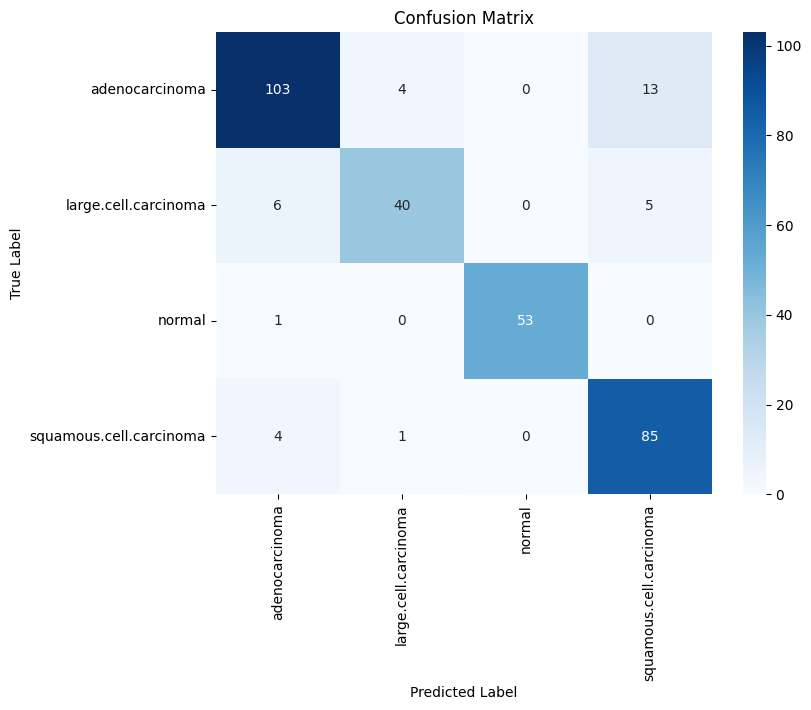

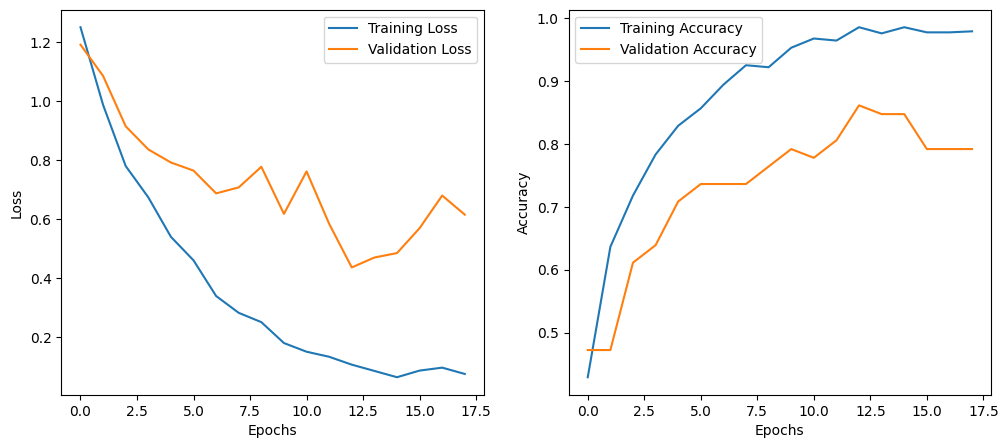

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.optim.lr_scheduler import StepLR

# Set dataset path here (adjust to your Kaggle environment)
dataset_path = '/kaggle/input/chest-ctscan-images/Data'

# Transformations for the training dataset (including augmentation)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomRotation(20),  # Rotate images up to 20 degrees
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Randomly crop to 224x224
    transforms.RandomAffine(degrees=10, shear=5),  # Apply random affine transformations
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize images
])

# Transformations for the validation dataset (no augmentation)
valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize images
])

# Load the ImageFolder dataset with the specified transformations
train_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, "train"), transform=train_transforms)
valid_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, "valid"), transform=valid_transforms)
test_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, "test"), transform=valid_transforms)  # Use validation transforms for test data

# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Shuffle training data
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)  # Do not shuffle validation data
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # Do not shuffle test data

# Print the mapping of class names to indices
print("Classes:", train_dataset.class_to_idx)

class CustomEfficientNetB0(nn.Module):
    def __init__(self, num_classes):
        super(CustomEfficientNetB0, self).__init__()
        self.efficientnet = models.efficientnet_b0(weights='DEFAULT')
        in_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.efficientnet(x)

# Instantiate model
num_classes = len(train_dataset.classes)  # Automatically determine the number of classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomEfficientNetB0(num_classes=num_classes).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=15, gamma=0.5)

# Function to train the model
def train_model(model, train_loader, valid_loader, epochs, save_path, early_stopping_patience):
    best_acc = 0.0
    patience_counter = 0
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total += labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()

        train_losses.append(total_loss / len(train_loader))
        train_acc = correct / total
        train_accs.append(train_acc)

        # Validation phase
        model.eval()
        total_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                total += labels.size(0)
                correct += (outputs.argmax(dim=1) == labels).sum().item()

        valid_losses.append(total_loss / len(valid_loader))
        valid_acc = correct / total
        valid_accs.append(valid_acc)

        # Save the best model
        if valid_acc > best_acc:
            best_acc = valid_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f'Early stopping after {epoch + 1} epochs.')
                break

        print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}, '
              f'Val Loss: {valid_losses[-1]:.4f}, Val Acc: {valid_acc:.4f}')

    return train_losses, valid_losses, train_accs, valid_accs

# Function to evaluate the model
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    return test_acc, None

# Visualizing training results function
def plot_training(train_losses, valid_losses, train_accs, valid_accs):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(valid_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Training Accuracy')
    plt.plot(valid_accs, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# Train the model
train_losses, valid_losses, train_accs, valid_accs = train_model(
    model, train_loader, valid_loader, epochs=100,
    save_path="best_efficientnet_model.pth", early_stopping_patience=5
)

# Load the best model
model.load_state_dict(torch.load("best_efficientnet_model.pth"))
model.to(device)

# Evaluate on the test set
test_acc, _ = evaluate(model, test_loader)
print(f"Best Test Accuracy for EfficientNet: {test_acc:.2f}%")

# Generate and plot the confusion matrix for the best model
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Plot confusion matrix, assuming class names are available
plot_confusion_matrix(cm, test_loader.dataset.classes)

# Visualize the training results
plot_training(train_losses, valid_losses, train_accs, valid_accs)

✅ Classes: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


Epoch [1/50] - Train Loss: 1.0891, Train Acc: 0.5759 - Val Loss: 1.1594, Val Acc: 0.3611
Epoch [2/50] - Train Loss: 0.8205, Train Acc: 0.7553 - Val Loss: 0.9047, Val Acc: 0.6667
Epoch [3/50] - Train Loss: 0.6533, Train Acc: 0.8548 - Val Loss: 1.3239, Val Acc: 0.6250
Epoch [4/50] - Train Loss: 0.5651, Train Acc: 0.9135 - Val Loss: 1.0061, Val Acc: 0.6944
Epoch [5/50] - Train Loss: 0.5670, Train Acc: 0.8956 - Val Loss: 0.8221, Val Acc: 0.7361
Epoch [6/50] - Train Loss: 0.5090, Train Acc: 0.9429 - Val Loss: 0.7846, Val Acc: 0.7361
Epoch [7/50] - Train Loss: 0.4652, Train Acc: 0.9527 - Val Loss: 0.8303, Val Acc: 0.7917
Epoch [8/50] - Train Loss: 0.4794, Train Acc: 0.9511 - Val Loss: 0.8383, Val Acc: 0.7778
Epoch [9/50] - Train Loss: 0.4248, Train Acc: 0.9788 - Val Loss: 0.7570, Val Acc: 0.8056
Epoch [10/50] - Train Loss: 0.4432, Train Acc: 0.9869 - Val Loss: 0.7960, Val Acc: 0.7778
Epoch [11/50] - Train Loss: 0.4436, Train Acc: 0.9804 - Val Loss: 0.7383, Val Acc: 0.8056
Epoch [12/50] - Tra

/tmp/ipykernel_31/479797166.py:158: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


🎯 Test Accuracy: 86.35%


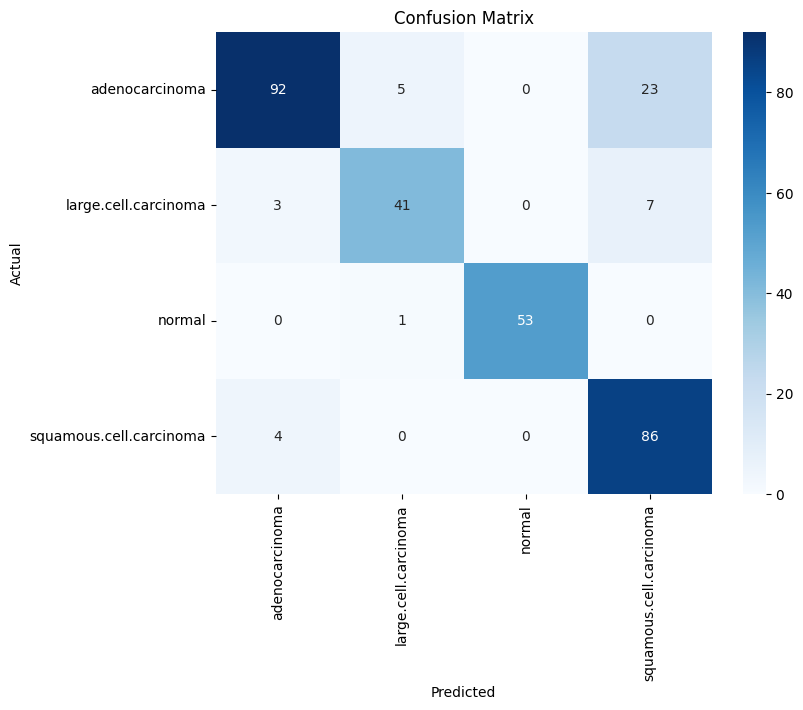

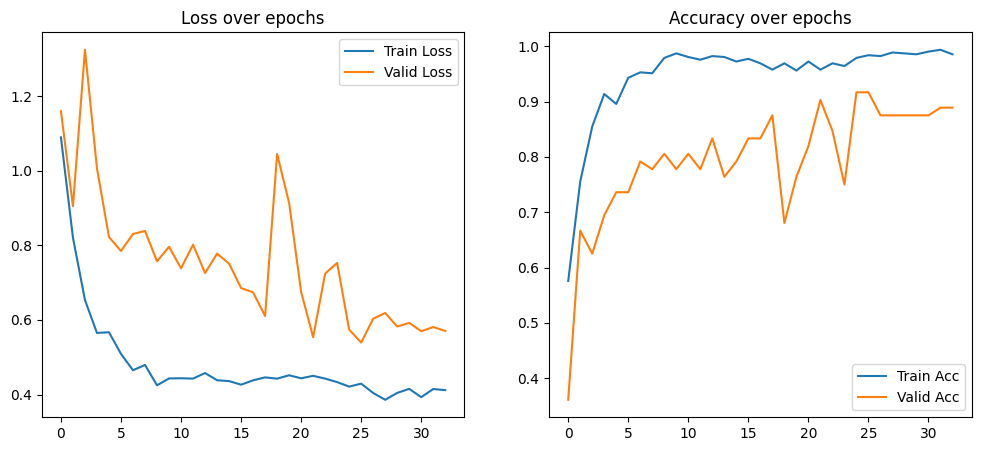

In [1]:
# ✅ Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ✅ Set dataset path
dataset_path = '/kaggle/input/chest-ctscan-images/Data'

# ✅ Strong Data Augmentation
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=10, shear=5),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ✅ Load Datasets
train_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, "train"), transform=train_transforms)
valid_dataset = datasets.ImageFolder(root=os.path.join(dataset_path, "valid"), transform=valid_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(dataset_path, "test"), transform=valid_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("✅ Classes:", train_dataset.class_to_idx)

# ✅ Custom EfficientNetB0
class CustomEfficientNetB0(nn.Module):
    def __init__(self, num_classes):
        super(CustomEfficientNetB0, self).__init__()
        self.efficientnet = models.efficientnet_b0(weights='DEFAULT')
        in_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        return self.efficientnet(x)

# ✅ Model Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomEfficientNetB0(num_classes=len(train_dataset.classes)).to(device)

# ✅ Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # ← softens targets slightly
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

# ✅ Training function
def train_model(model, train_loader, valid_loader, epochs, save_path, early_stopping_patience=5):
    best_val_loss = float('inf')
    patience_counter = 0

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)

        # ✅ Validation phase
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)

        valid_loss = total_loss / len(valid_loader)
        valid_acc = correct / total
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} - Val Loss: {valid_losses[-1]:.4f}, Val Acc: {valid_accs[-1]:.4f}")

        scheduler.step()

        # ✅ Early Stopping Check
        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"🚨 Early stopping after {epoch+1} epochs.")
                break

    return train_losses, valid_losses, train_accs, valid_accs

# ✅ Evaluate function
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    preds, labels_list = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds.extend(outputs.argmax(1).cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return acc, preds, labels_list

# ✅ Training!
train_losses, valid_losses, train_accs, valid_accs = train_model(
    model, train_loader, valid_loader,
    epochs=50,
    save_path="best_model.pth",
    early_stopping_patience=7
)

# ✅ Load best model
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)

# ✅ Test evaluation
test_acc, preds, labels_list = evaluate_model(model, test_loader)
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")

# ✅ Confusion Matrix
cm = confusion_matrix(labels_list, preds)

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(cm, test_loader.dataset.classes)

# ✅ Plot training history
def plot_history(train_losses, valid_losses, train_accs, valid_accs):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(valid_losses, label='Valid Loss')
    plt.legend()
    plt.title('Loss over epochs')

    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(valid_accs, label='Valid Acc')
    plt.legend()
    plt.title('Accuracy over epochs')

    plt.show()

plot_history(train_losses, valid_losses, train_accs, valid_accs)


In [6]:
import torchvision.models as models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class CustomEfficientNetB0(nn.Module):
    def __init__(self, num_classes):
        super(CustomEfficientNetB0, self).__init__()

        # Load pre-trained EfficientNet-B0
        self.efficientnet = models.efficientnet_b0(weights='DEFAULT')

        # Modify the classifier to match the number of classes
        in_features = self.efficientnet.classifier[-1].in_features  # Correctly access the last layer input features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(0.5),                        # Dropout layer
            nn.Linear(in_features, num_classes)     # Modify the output layer
        )

    def forward(self, x):
        return self.efficientnet(x)

# Instantiate model
num_classes = 4  # Adjust this to your actual number of classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomEfficientNetB0(num_classes=num_classes).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=15, gamma=0.5)  # Reduce learning rate every 15 epochs

# Function to train the model
def train_model(model, train_loader, valid_loader, epochs, save_path, early_stopping_patience):
    best_acc = 0.0
    patience_counter = 0
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total += labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()

        train_losses.append(total_loss / len(train_loader))
        train_acc = correct / total
        train_accs.append(train_acc)

        # Validation phase
        model.eval()
        total_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                total += labels.size(0)
                correct += (outputs.argmax(dim=1) == labels).sum().item()

        valid_losses.append(total_loss / len(valid_loader))
        valid_acc = correct / total
        valid_accs.append(valid_acc)

        # Save the best model
        if valid_acc > best_acc:
            best_acc = valid_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f'Early stopping after {epoch + 1} epochs.')
                break

        print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}, '
              f'Val Loss: {valid_losses[-1]:.4f}, Val Acc: {valid_acc:.4f}')

    return train_losses, valid_losses, train_accs, valid_accs

# Function to evaluate the model
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    return test_acc

# Function to visualize training results
def plot_training(train_losses, valid_losses, train_accs, valid_accs):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(valid_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Training Accuracy')
    plt.plot(valid_accs, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# Assuming train_loader and valid_loader are defined
# Please replace train_dataset_loader and valid_dataset_loader with your actual DataLoader instances
train_model(model, train_loader=train_dataset_loader, valid_loader=valid_dataset_loader, epochs=100,
            save_path="best_efficientnet_model.pth", early_stopping_patience=5)

# Load the best model
model.load_state_dict(torch.load("best_efficientnet_model.pth"))
model.to(device)

# Evaluate on the test set
test_acc = evaluate(model=model, test_loader=test_dataset_loader)
print(f"Best Test Accuracy for EfficientNet: {test_acc:.2f}%")

# Generate and plot the confusion matrix for the best model
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_dataset_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Replace 'class_names' with the actual class names corresponding to your dataset
plot_confusion_matrix(cm=cm, class_names=['squamous.cell.carcinoma', 'adenocarcinoma', 'large.cell.carcinoma', 'normal'])

# Visualize the training results
# Ensure you save train_losses_list, valid_losses_list, train_accuracy_list, and valid_accuracy_list
plot_training(train_losses=train_losses_list, valid_losses=valid_losses_list,
              train_accs=train_accuracy_list, valid_accs=valid_accuracy_list)


NameError: name 'train_dataset_loader' is not defined